In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import IsolationForest
from scipy.stats import zscore

In [2]:
# load dataset
data = pd.read_csv('/content/bank_transactions_data_2.csv')
data

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,11/04/2023 16:29,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,04/11/2024 08:08
1,TX000002,AC00455,376.24,27/06/2023 16:44,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,04/11/2024 08:09
2,TX000003,AC00019,126.29,10/07/2023 18:16,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,04/11/2024 08:07
3,TX000004,AC00070,184.50,05/05/2023 16:32,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,04/11/2024 08:09
4,TX000005,AC00411,13.45,16/10/2023 17:51,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,04/11/2024 08:06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2507,TX002508,AC00297,856.21,26/04/2023 17:09,Credit,Colorado Springs,D000625,21.157.41.17,M072,Branch,33,Doctor,109,1,12690.79,04/11/2024 08:11
2508,TX002509,AC00322,251.54,22/03/2023 17:36,Debit,Tucson,D000410,49.174.157.140,M029,Branch,48,Doctor,177,1,254.75,04/11/2024 08:11
2509,TX002510,AC00095,28.63,21/08/2023 17:08,Debit,San Diego,D000095,58.1.27.124,M087,Branch,56,Retired,146,1,3382.91,04/11/2024 08:08
2510,TX002511,AC00118,185.97,24/02/2023 16:24,Debit,Denver,D000634,21.190.11.223,M041,Online,23,Student,19,1,1776.91,04/11/2024 08:12


In [3]:
# missing values
data.isnull().sum()

,0
TransactionID,0
AccountID,0
TransactionAmount,0
TransactionDate,0
TransactionType,0
Location,0
DeviceID,0
IP Address,0
MerchantID,0
Channel,0


In [4]:
data.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966
std,291.946243,17.792198,69.963757,0.602662,3900.942499
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


<Axes: >

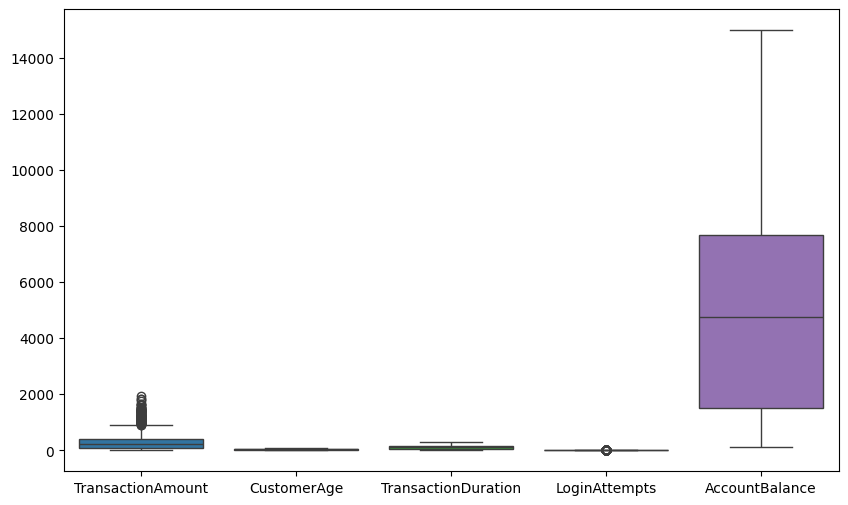

In [5]:
# box plot
plt.figure(figsize=(10, 6))
sns.boxplot(data)

In [6]:
# highest 5 transaction amount
data.nlargest(5, 'TransactionAmount')

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
653,TX000654,AC00423,1919.11,27/06/2023 17:48,Debit,Portland,D000191,207.157.126.125,M033,ATM,30,Doctor,161,1,11090.24,04/11/2024 08:10
1438,TX001439,AC00179,1831.02,15/09/2023 17:31,Credit,Columbus,D000246,141.121.30.32,M012,Online,62,Doctor,83,1,11498.01,04/11/2024 08:10
340,TX000341,AC00107,1830.00,01/03/2023 16:31,Debit,San Antonio,D000436,62.27.235.199,M082,Online,55,Engineer,238,1,2235.70,04/11/2024 08:11
1634,TX001635,AC00358,1762.28,06/10/2023 16:05,Debit,Memphis,D000008,26.105.49.129,M066,ATM,24,Student,150,1,1380.34,04/11/2024 08:10
2414,TX002415,AC00028,1664.33,25/09/2023 17:11,Debit,San Antonio,D000072,116.106.207.139,M064,Branch,18,Student,65,1,1588.31,04/11/2024 08:07


In [7]:
# least transaction made
data.nsmallest(5, 'TransactionAmount')

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
1354,TX001355,AC00097,0.26,23/11/2023 16:14,Debit,Oklahoma City,D000239,60.197.167.40,M090,Online,20,Student,173,1,1833.67,04/11/2024 08:07
2253,TX002254,AC00236,0.32,04/08/2023 17:44,Debit,Boston,D000129,173.135.78.201,M033,ATM,39,Engineer,136,1,7158.58,04/11/2024 08:09
2259,TX002260,AC00324,0.45,26/07/2023 17:29,Debit,Kansas City,D000334,5.50.152.168,M078,Branch,34,Engineer,172,1,8670.23,04/11/2024 08:10
1879,TX001880,AC00460,0.84,01/01/2024 16:45,Debit,Austin,D000527,136.172.149.77,M036,ATM,52,Engineer,31,1,2207.54,04/11/2024 08:07
929,TX000930,AC00329,0.86,13/02/2023 17:49,Debit,Colorado Springs,D000082,120.16.186.17,M050,ATM,25,Student,139,1,1357.22,04/11/2024 08:12


In [8]:
# highest account balance
data.nlargest(5, 'AccountBalance')

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
914,TX000915,AC00171,577.73,10/11/2023 16:26,Debit,San Jose,D000527,93.146.251.20,M033,ATM,37,Doctor,63,1,14977.99,04/11/2024 08:06
233,TX000234,AC00345,91.48,23/01/2023 16:50,Debit,Fort Worth,D000295,160.74.183.38,M081,ATM,51,Doctor,141,1,14942.78,04/11/2024 08:09
1839,TX001840,AC00035,813.78,07/08/2023 17:42,Credit,Atlanta,D000627,101.90.40.193,M012,ATM,54,Doctor,55,1,14935.50,04/11/2024 08:08
1726,TX001727,AC00120,85.73,01/03/2023 16:09,Debit,Virginia Beach,D000072,134.222.122.238,M100,ATM,41,Doctor,266,1,14928.35,04/11/2024 08:08
52,TX000053,AC00115,85.43,07/06/2023 16:45,Debit,Virginia Beach,D000235,194.174.252.1,M078,Branch,67,Doctor,145,1,14904.90,04/11/2024 08:06


In [9]:
# print location column
data['Location'].unique()


array(['San Diego', 'Houston', 'Mesa', 'Raleigh', 'Atlanta',
       'Oklahoma City', 'Seattle', 'Indianapolis', 'Detroit', 'Nashville',
       'Albuquerque', 'Memphis', 'Louisville', 'Denver', 'Austin',
       'Columbus', 'Los Angeles', 'Las Vegas', 'Fort Worth', 'Miami',
       'Milwaukee', 'Baltimore', 'New York', 'San Francisco', 'San Jose',
       'San Antonio', 'Philadelphia', 'Charlotte', 'Tucson', 'Chicago',
       'Sacramento', 'Kansas City', 'Omaha', 'Virginia Beach', 'Dallas',
       'Boston', 'Jacksonville', 'Phoenix', 'Washington', 'El Paso',
       'Colorado Springs', 'Fresno', 'Portland'], dtype=object)

In [10]:
# drop transaction id,account id , device id, ip address, merchant id, location
df = data.drop(['TransactionID', 'AccountID', 'DeviceID', 'IP Address', 'MerchantID', 'Location', 'PreviousTransactionDate', 'TransactionDate'], axis=1)
df

,TransactionAmount,TransactionType,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,14.09,Debit,ATM,70,Doctor,81,1,5112.21
1,376.24,Debit,ATM,68,Doctor,141,1,13758.91
2,126.29,Debit,Online,19,Student,56,1,1122.35
3,184.50,Debit,Online,26,Student,25,1,8569.06
4,13.45,Credit,Online,26,Student,198,1,7429.40
...,...,...,...,...,...,...,...,...
2507,856.21,Credit,Branch,33,Doctor,109,1,12690.79
2508,251.54,Debit,Branch,48,Doctor,177,1,254.75
2509,28.63,Debit,Branch,56,Retired,146,1,3382.91
2510,185.97,Debit,Online,23,Student,19,1,1776.91


In [11]:
from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder instance
encoder = LabelEncoder()

# Encode each column individually
for column in ['TransactionType', 'Channel', 'CustomerOccupation']:
    df[column] = encoder.fit_transform(df[column])

In [12]:
df

,TransactionAmount,TransactionType,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,14.09,1,0,70,0,81,1,5112.21
1,376.24,1,0,68,0,141,1,13758.91
2,126.29,1,2,19,3,56,1,1122.35
3,184.50,1,2,26,3,25,1,8569.06
4,13.45,0,2,26,3,198,1,7429.40
...,...,...,...,...,...,...,...,...
2507,856.21,0,1,33,0,109,1,12690.79
2508,251.54,1,1,48,0,177,1,254.75
2509,28.63,1,1,56,2,146,1,3382.91
2510,185.97,1,2,23,3,19,1,1776.91


In [13]:
# scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df1 = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
df1


,TransactionAmount,TransactionType,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,-0.971275,0.540538,-1.225361,1.423718,-1.337394,-0.552443,-0.206794,-0.000537
1,0.269440,0.540538,-1.225361,1.311287,-1.337394,0.305314,-0.206794,2.216472
2,-0.586882,0.540538,1.247014,-1.443277,1.319064,-0.909842,-0.206794,-1.023534
3,-0.387456,0.540538,1.247014,-1.049768,1.319064,-1.353017,-0.206794,0.885797
4,-0.973468,-1.850010,1.247014,-1.049768,1.319064,1.120184,-0.206794,0.593589
...,...,...,...,...,...,...,...,...
2507,1.913802,-1.850010,0.010826,-0.656259,-1.337394,-0.152156,-0.206794,1.942606
2508,-0.157779,0.540538,0.010826,0.186975,-1.337394,0.819969,-0.206794,-1.245986
2509,-0.921462,0.540538,0.010826,0.636700,0.433578,0.376794,-0.206794,-0.443928
2510,-0.382420,0.540538,1.247014,-1.218415,1.319064,-1.438793,-0.206794,-0.855705


In [14]:
# correlation matrix
corr_matrix = df1.corr()
corr_matrix

,TransactionAmount,TransactionType,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
TransactionAmount,1.000000,-0.016495,-0.014741,-0.025616,0.026313,0.004359,-0.008445,-0.025165
TransactionType,-0.016495,1.000000,-0.207020,-0.044948,0.001583,0.001924,-0.017730,-0.018714
Channel,-0.014741,-0.207020,1.000000,-0.012149,-0.002951,-0.010566,0.003056,0.007980
CustomerAge,-0.025616,-0.044948,-0.012149,1.000000,-0.378925,-0.017936,0.007653,0.319942
CustomerOccupation,0.026313,0.001583,-0.002951,-0.378925,1.000000,-0.003536,-0.019739,-0.672282
TransactionDuration,0.004359,0.001924,-0.010566,-0.017936,-0.003536,1.000000,0.032639,0.005577
LoginAttempts,-0.008445,-0.017730,0.003056,0.007653,-0.019739,0.032639,1.000000,0.014999
AccountBalance,-0.025165,-0.018714,0.007980,0.319942,-0.672282,0.005577,0.014999,1.000000


In [15]:
# Apply PCA for dimensionality reduction (2 components)
pca = PCA(n_components=4)
X_pca = pca.fit_transform(df)
X_pca

array([[-1.52263574e+00, -2.83578319e+02, -3.84504711e+01,
         2.48369956e+01],
       [ 8.64446963e+03,  9.50304224e+01,  2.03254404e+01,
         1.09188755e+01],
       [-3.99166114e+03, -1.78914969e+02, -6.29320639e+01,
        -2.03827412e+01],
       ...,
       [-1.73085950e+03, -2.72226593e+02,  2.67693521e+01,
         1.36990350e+01],
       [-3.33721392e+03, -1.18041161e+02, -1.00083254e+02,
        -1.74710622e+01],
       [-4.98296848e+03, -6.39668160e+01, -2.59998833e+01,
        -1.36141352e+01]])

In [21]:
# convert x_pca to dataframe
X_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3', 'PC4'])
X_pca

,PC1,PC2,PC3,PC4
0,-1.522636,-283.578319,-38.450471,24.836996
1,8644.469635,95.030422,20.325440,10.918875
2,-3991.661142,-178.914969,-62.932064,-20.382741
3,3454.924261,-106.633645,-94.739356,-24.357182
4,2315.608816,-279.645077,78.562611,-21.957938
...,...,...,...,...
2507,7575.389403,572.975314,-11.940096,-22.175019
2508,-4859.440851,-55.202379,57.850351,10.692549
2509,-1730.859504,-272.226593,26.769352,13.699035
2510,-3337.213924,-118.041161,-100.083254,-17.471062


In [23]:
# correlation
corr_matrix = X_pca.corr()
corr_matrix

,PC1,PC2,PC3,PC4
PC1,1.000000e+00,-1.263620e-15,-3.263054e-16,-1.617897e-15
PC2,-1.263620e-15,1.000000e+00,4.748907e-16,-2.064501e-16
PC3,-3.263054e-16,4.748907e-16,1.000000e+00,1.169034e-15
PC4,-1.617897e-15,-2.064501e-16,1.169034e-15,1.000000e+00


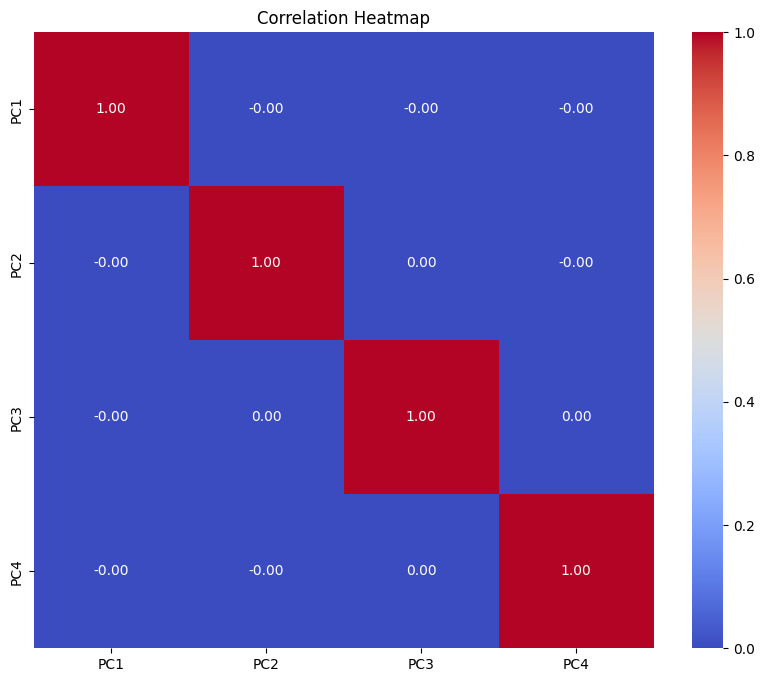

In [24]:
# heat ap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [73]:
# Apply t-SNE for nonlinear dimensionality reduction
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(df)
X_tsne

array([[ 12.178817 , -30.014257 ],
       [ 44.92915  ,  -7.86452  ],
       [ -6.3114424,  60.100784 ],
       ...,
       [-18.578049 , -28.52521  ],
       [ -4.356708 ,  60.927975 ],
       [-47.33888  ,  34.86325  ]], dtype=float32)

In [80]:
# Apply K-Means Clustering
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df["KMeans_Cluster"] = kmeans.fit_predict(df)
kmeans_labels = kmeans.labels_  # Get cluster labels from KMeans
kmeans_silhouette = silhouette_score(df, kmeans_labels)
print("KMeans Silhouette Score:", kmeans_silhouette)

KMeans Silhouette Score: 0.3243613528531376


In [81]:
# Apply DBSCAN Clustering
dbscan = DBSCAN(eps=2, min_samples=10)  # eps adjusted based on dataset scale
df["DBSCAN_Cluster"] = dbscan.fit_predict(df)
dbscan_labels = dbscan.labels_  # Get cluster labels from DBSCAN
dbscan_silhouette = silhouette_score(df, dbscan_labels)
print("DBSCAN Silhouette Score:", dbscan_silhouette)

DBSCAN Silhouette Score: 0.33853302860333717


In [82]:
# Outlier Detection using Z-Score
z_scores = np.abs(zscore(df))
df["Outlier_ZScore"] = (z_scores > 3).any(axis=1).astype(int)

In [83]:
# Outlier Detection using Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df["Outlier_IsoForest"] = iso_forest.fit_predict(df)
df["Outlier_IsoForest"] = df["Outlier_IsoForest"].map({1: 0, -1: 1})  # Convert -1 (outlier) to 1


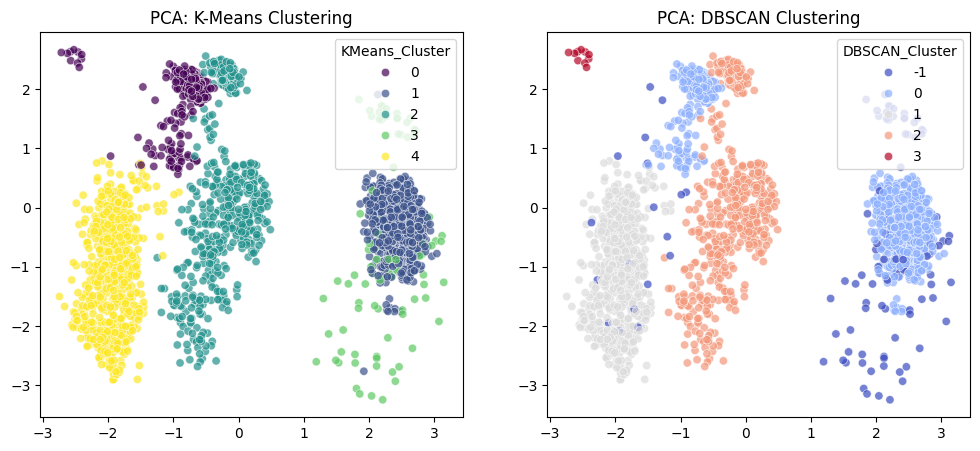

In [84]:
# Visualizing PCA and Clustering Results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df["KMeans_Cluster"], palette="viridis", alpha=0.7)
plt.title("PCA: K-Means Clustering")

plt.subplot(1, 2, 2)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df["DBSCAN_Cluster"], palette="coolwarm", alpha=0.7)
plt.title("PCA: DBSCAN Clustering")

plt.show()


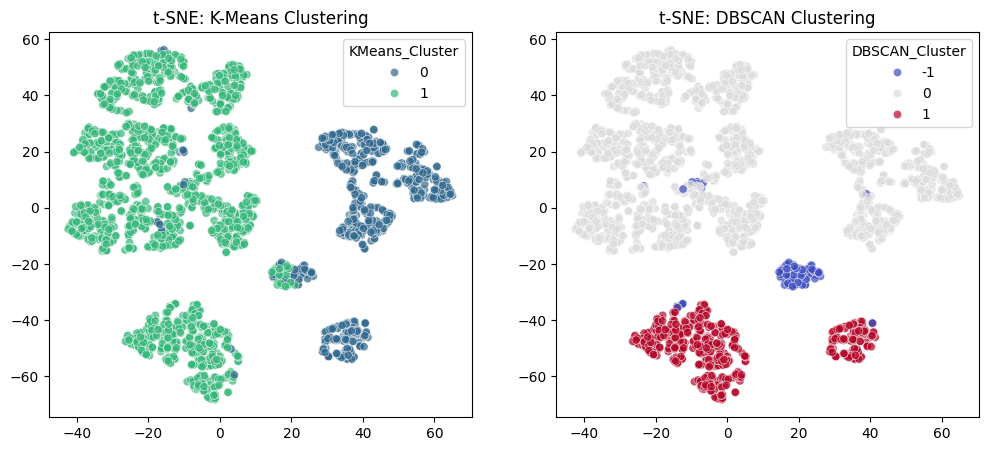

In [52]:
# Visualizing t-SNE Results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=df["KMeans_Cluster"], palette="viridis", alpha=0.7)
plt.title("t-SNE: K-Means Clustering")

plt.subplot(1, 2, 2)
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=df["DBSCAN_Cluster"], palette="coolwarm", alpha=0.7)
plt.title("t-SNE: DBSCAN Clustering")

plt.show()

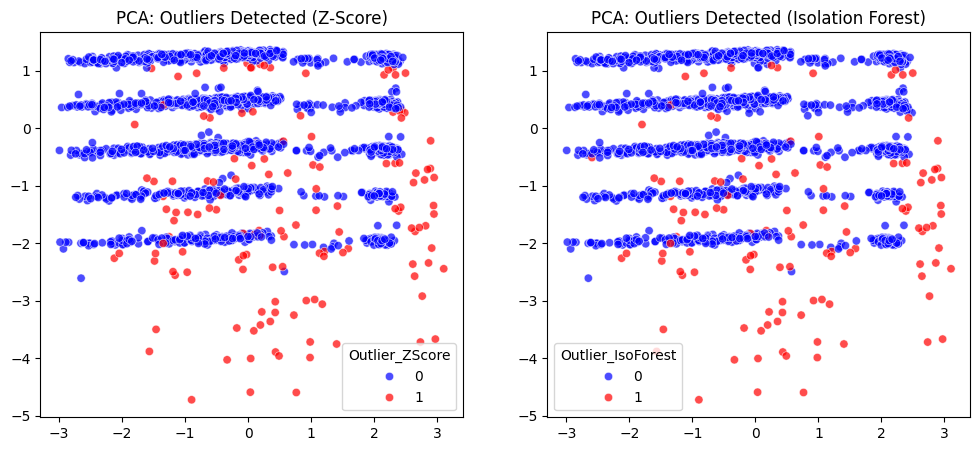

In [53]:
# Outlier Visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df["Outlier_ZScore"], palette={0: "blue", 1: "red"}, alpha=0.7)
plt.title("PCA: Outliers Detected (Z-Score)")

plt.subplot(1, 2, 2)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df["Outlier_IsoForest"], palette={0: "blue", 1: "red"}, alpha=0.7)
plt.title("PCA: Outliers Detected (Isolation Forest)")

plt.show()
